# loading data 

In [2]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.stats import norm
from scipy.optimize import curve_fit

In [11]:
tags = [
#        "1_12062026_purewater_pure",
#        "2_12062026_purewater_pure",
#        "1_15062026_purewater_pure",
#        "2_15062026_purewater_pure",
#        "2_16062026_purewater_right",
        
]

experiment_data = {}  # Master dictionary for all data

for tag in tags:
    experiment_data[tag] = {
        "times": None,
        "temps": None,
        "volume": None
    }

    # Load times
    times_file_path = f'C:/Users/lucas/OneDrive/Bureaublad/TN/BEP/Times/times_{tag}.txt'
    try:
        experiment_data[tag]["times"] = np.loadtxt(times_file_path, dtype=int)
    except FileNotFoundError:
        print(f"Warning: File not found - {times_file_path}")

    # Load temps
    # Extract base tag (remove volume information)
    base_tag = "_".join(tag.split("_")[:-1])  # Removes last part (e.g., "50microL" or "100microL")
    # Load temperature data
    temp_file_path = f'C:/Users/lucas/OneDrive/Bureaublad/TN/BEP/Code/temp_{base_tag}.txt'
    try:
        experiment_data[tag]["temps"] = np.loadtxt(temp_file_path, dtype=float)
    except FileNotFoundError:
        print(f"Warning: File not found - {temp_file_path}")

    # Assign volume based on tag
    if "50microL" in tag:
        experiment_data[tag]["volume"] = 50e-3
    elif "100microL" in tag:
        experiment_data[tag]["volume"] = 100e-3
    else:
        experiment_data[tag]["volume"] = 50e-3  # Default

# Print out for verification
for tag, data in experiment_data.items():
    print(f"Experiment: {tag}")
    print(f"  Times: {len(data['times']) if data['times'] is not None else 'Missing'}")
    print(f"  Temps: {len(data['temps']) if data['temps'] is not None else 'Missing'}")
    print(f"  Volume: {data['volume']*1e3} microL\n")

Experiment: 2_16062026_purewater_right
  Times: 2
  Temps: 3572
  Volume: 50.0 microL



In [7]:
# Existing tags
tags = [
    # "1_12062026_purewater_pure",
    # "2_12062026_purewater_pure"
]

# Master dictionary for all data
experiment_data = {}

# Base file paths
base_path = "C:/Users/lucas/OneDrive/Bureaublad/TN/BEP/Code"

for tag in tags:
    experiment_data[tag] = {
        "times": None,
        "temps": None,
        "volume": None
    }
    
    # Determine correct file path
    if any(date in tag for date in ["14okt", "15okt", "6nov", "8nov", "12nov"]):
        times_file_path = f'{wietske_path}times_{tag}.txt'
        temp_file_path = f'{wietske_path}temp_{tag}.txt'
    else:
        times_file_path = f'{base_path}times_{tag}.txt'
        base_tag = "_".join(tag.split("_")[:-1])  # Removes last part (e.g., "50microL" or "100microL")
        temp_file_path = f'{base_path}temp_{base_tag}.txt'
    
    # Load times
    try:
        experiment_data[tag]["times"] = np.loadtxt(times_file_path, dtype=int)
    except FileNotFoundError:
        print(f"Warning: File not found - {times_file_path}")
    
    # Load temps
    try:
        experiment_data[tag]["temps"] = np.loadtxt(temp_file_path, dtype=float)
    except FileNotFoundError:
        print(f"Warning: File not found - {temp_file_path}")
    
    # Assign volume based on tag
    if "50microL" in tag:
        experiment_data[tag]["volume"] = 50e-3
    elif "100microL" in tag:
        experiment_data[tag]["volume"] = 100e-3
    else:
        experiment_data[tag]["volume"] = 50e-3  # Default

# Print out for verification
for tag, data in experiment_data.items():
    print(f"Experiment: {tag}")
    print(f"  Times: {len(data['times']) if data['times'] is not None else 'Missing'}")
    print(f"  Temps: {len(data['temps']) if data['temps'] is not None else 'Missing'}")
    print(f"  Volume: {data['volume']*1e3} microL\n")


Experiment: 1_12062026_purewater_pure
  Times: Missing
  Temps: Missing
  Volume: 50.0 microL

Experiment: 2_12062026_purewater_pure
  Times: Missing
  Temps: Missing
  Volume: 50.0 microL



In [8]:
    """
    Parameters:
    - times_dict: Dictionary of freezing event times {"label": times_array}.
    - temp_dict: Dictionary of temperatures {"label": temp_array}.
    - num_droplets: Total number of droplets.
    - V: Volume in cm³ (e.g., 50e-3 for 50 µl).
    - time_step: time between measurements in seconds
    - labels: List of dataset labels.
    - xlim: Tuple specifying x-axis limits.
    - ylim: Tuple specifying y-axis limits (default: None).
    - colors: color for all experiments
    - names: legend name for all experiments
    - filename: Optional filename to save the plot (default: None).
    """

'\nParameters:\n- times_dict: Dictionary of freezing event times {"label": times_array}.\n- temp_dict: Dictionary of temperatures {"label": temp_array}.\n- num_droplets: Total number of droplets.\n- V: Volume in cm³ (e.g., 50e-3 for 50 µl).\n- time_step: time between measurements in seconds\n- labels: List of dataset labels.\n- xlim: Tuple specifying x-axis limits.\n- ylim: Tuple specifying y-axis limits (default: None).\n- colors: color for all experiments\n- names: legend name for all experiments\n- filename: Optional filename to save the plot (default: None).\n'

# 
frozen fraction 

In [12]:
def plot_frozen_fractions(times_dict, temp_dict, num_droplets, V, time_step, labels, xlim, ylim, colors, names, filename=None):
    """
    Plots frozen fractions and their errors for multiple datasets.
    """

    # Initialize plot
    plt.figure(figsize=(10, 6))
    

    # Iterate over datasets
    for idx, label in enumerate(labels):
        # Retrieve data for current label
        times = times_dict[label]
        temp = temp_dict[label]
        color = colors.get(label)
        name = names.get(label)
        num_droplets = len(times)
        
        # Initialize frozen fractions
        frozen_fractions = np.zeros(len(temp))

        # Update frozen fraction at each freezing event
        for i in range(len(times)):
            frozen_fractions[times[i]:] += 1 / num_droplets

        # Calculate error margins
        err_temp = 0.3 + 0.005 * np.abs(temp)
        asymm_temp_error = np.zeros(len(temp))

        for i in range(1, len(temp)):
            asymm_temp_error[i] = np.abs(temp[i] - temp[i - 1])

        # Confidence intervals for frozen fractions
        lower_bound, upper_bound = confidence_interval_95(frozen_fractions, num_droplets)
        error_bars_lower = np.abs(frozen_fractions - lower_bound)
        error_bars_upper = np.abs(upper_bound - frozen_fractions)

        
        # Plot frozen fractions
        if name: 
            plt.plot(temp, frozen_fractions, label=name, color=color)
        plt.plot(temp, frozen_fractions, color=color)

        # Add shaded error regions
        plt.fill_between(temp, 
                         frozen_fractions - error_bars_lower, 
                         frozen_fractions + error_bars_upper, 
                         color=color, alpha=0.1)

        plt.fill_betweenx(frozen_fractions, 
                          temp - np.sqrt(err_temp**2 + asymm_temp_error**2), 
                          temp + err_temp, 
                          color=color, alpha=0.1)
        

    # Plot customization
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Frozen Fraction')
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.grid(True)
    plt.legend(loc='best')
    plt.tight_layout()

    # Save or show the plot
    if filename:
        plt.savefig(filename)
    plt.show()
    
def confidence_interval_95(p_hat, N_all):
    z_alpha_over_2 = norm.ppf(0.975)
    sqrt_term = np.sqrt((p_hat * (1 - p_hat) / N_all) + (z_alpha_over_2**2 / (4 * N_all**2)))
    plus_minus_term = z_alpha_over_2 * sqrt_term
    adjustment_factor = 1 / (1 + (z_alpha_over_2**2 / N_all))
    
    # Compute the lower and upper bounds
    lower_bound = adjustment_factor * (p_hat + (z_alpha_over_2**2 / (2 * N_all)) - plus_minus_term)
    upper_bound = adjustment_factor * (p_hat + (z_alpha_over_2**2 / (2 * N_all)) + plus_minus_term)
    return lower_bound, upper_bound

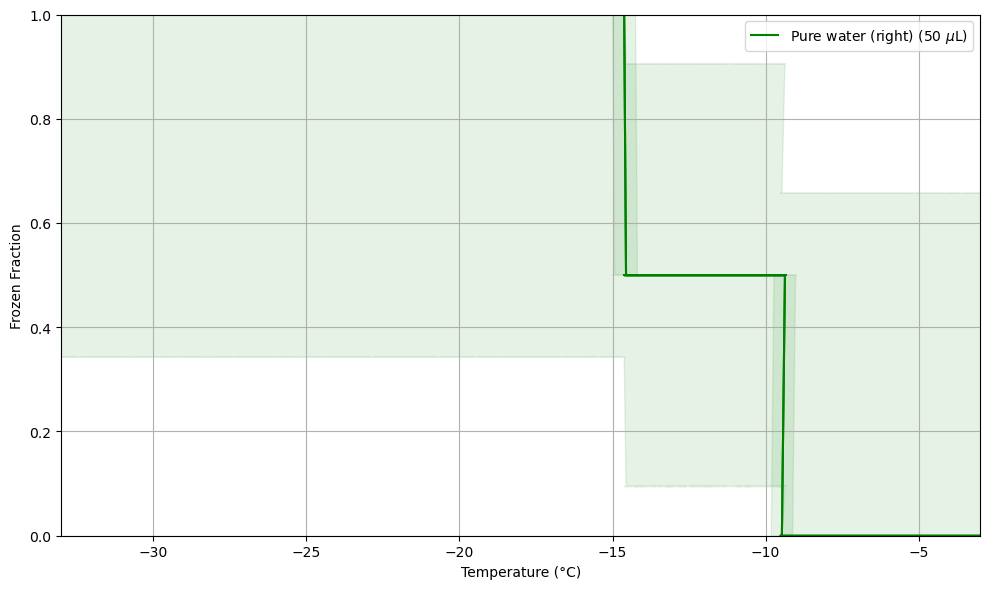

In [14]:
labels = [
#         "1_12062026_purewater_pure",
         "2_16062026_purewater_right"
]

color_dict = {
#        "1_12062026_purewater_pure": "blue",
        "2_16062026_purewater_right": "green"

}

name_dict = {
#        "1_12062026_purewater_pure": "Pure water (1) (50 $\mu$L)",
        "2_16062026_purewater_right": "Pure water (right) (50 $\mu$L)"
}

plot_frozen_fractions(
    times_dict={tag: experiment_data[tag]["times"] for tag in labels},  
    temp_dict={tag: experiment_data[tag]["temps"] for tag in labels},  
    num_droplets=96,  
    time_step=1,  
    V={tag: experiment_data[tag]["volume"] for tag in labels},  
    labels=labels,  
    xlim=(-33, -3),  
    ylim=(0, 1),  
    colors={tag: color_dict[tag] for tag in labels},
    names={tag: name_dict[tag] for tag in labels},
    filename="all_results"
)

# Cumulative nucleus spectrum:

In [15]:
def plot_cumulative_inp(times_dict, temp_dict, num_droplets, time_step, V_dict, labels, xlim, ylim, colors, names, filename=None):
    """
    Plots cumulative INP concentrations with error bars for multiple datasets.
    """

    plt.figure(figsize=(10,12))

    # Iterate over datasets
    for label in labels:
        temp = temp_dict[label]
        times = times_dict[label]
        V = V_dict[label]
        color = colors.get(label)
        name = names.get(label)

        num_droplets = len(times) # Set per dataset

        # Initialize frozen wells array
        frozen_wells = np.zeros(len(temp))

        # Update frozen wells for each freezing event
        for i in range(len(times)):
            frozen_wells[int(times[i]):] += 1

        # Calculate cumulative INP concentrations
        cumulative_inp = cum_inp(frozen_wells, num_droplets, V)

        # Calculate errors
        err_temp = 0.3 + 0.005 * np.abs(temp)
        asymm_temp_error = np.zeros(len(temp))
        for i in range(1, len(temp)):
            asymm_temp_error[i] = np.abs(temp[i] - temp[i - 1])

        lower_bound, upper_bound = confidence_interval_95(frozen_wells / num_droplets, num_droplets)
        error_bars = [
            cumulative_inp - cum_inp(lower_bound * num_droplets, num_droplets, V),
            cum_inp(upper_bound * num_droplets, num_droplets, V) - cumulative_inp
        ]

        # Plot cumulative INP
        plt.errorbar(temp, cumulative_inp, yerr=error_bars, xerr=err_temp, 
                     color=color, fmt='.', markersize = 3, label=name, elinewidth=0.05)

    # Customize plot
    plt.xlabel("Temperature (°C)", fontsize=12)
    plt.ylabel("Cumulative INP concentration (L$^{-1}$ water)", fontsize=12)
    plt.legend(loc="best", fontsize=6, markerscale=6)
    plt.yscale('log')
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.grid(True, linestyle="--", alpha=0.7)

    # Save or show the plot
    if filename:
        plt.savefig(filename)
    plt.show()

def cum_inp(frozenwells, num_droplets, V):
    unfrozenwells = num_droplets - frozenwells
    masked = unfrozenwells <=0
    unfrozenwells[masked] = 1e-5 #avoid log(0)
    result = (np.log(num_droplets)-np.log(unfrozenwells))/V
    result[masked] = np.nan #mask those values in plot
    return result

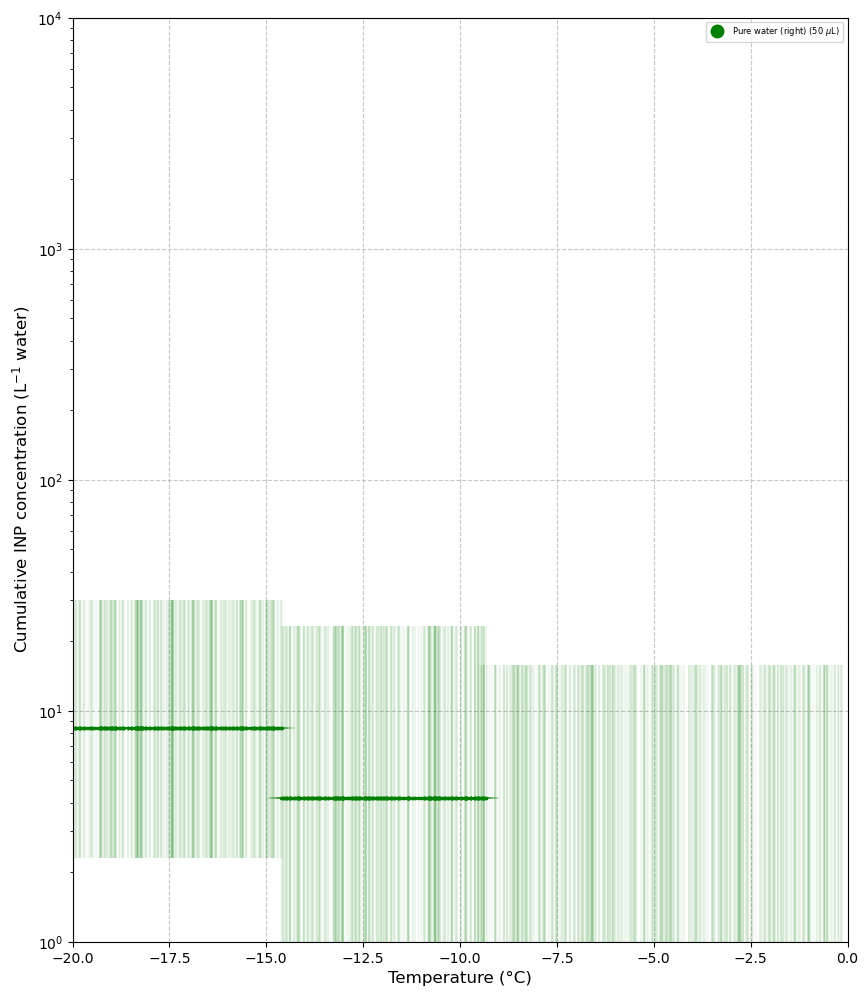

In [16]:
plot_cumulative_inp(
    times_dict={tag: experiment_data[tag]["times"] for tag in labels},  
    temp_dict={tag: experiment_data[tag]["temps"] for tag in labels},  
    num_droplets=96,  
    time_step=1,  
    V_dict={tag: experiment_data[tag]["volume"] for tag in labels},  
    labels=labels,  
    xlim=(-20,0),  
    ylim=(1e0, 1e4),  
    colors={tag: color_dict[tag] for tag in labels}, 
    names={tag: name_dict[tag] for tag in labels}, 
    filename = "cum_inp"
)

# Mean and onset freezing temperatures 

In [17]:
def freezing_point_and_onset(times_dict, temp_dict, V_dict, time_step, labels, colors, xlim=None, ylim=None, filename=None):
    """
    Gives mean freezing point and onset freezing temperature for multiple datasets
    """

    # Iterate over datasets
    for label in labels:
        temp = temp_dict[label]
        times = times_dict[label]
        V = V_dict[label]
        
        freezing_temps = temp[times]
        
        # Calculate mean and standard deviation
        mean_freezing = np.mean(freezing_temps)
        std_freezing = np.std(freezing_temps)

        print(f"Mean freezing point for {label}: {mean_freezing:.2f} °C") #50microliter
        print(f"Standard deviation for {label}: {std_freezing:.2f} °C")

        #getting onset temp 
        print(f"Onset freezing temp for {label} is: {freezing_temps[0]} °C")
        print()

In [18]:
freezing_point_and_onset(
    times_dict={tag: experiment_data[tag]["times"] for tag in labels},  
    temp_dict={tag: experiment_data[tag]["temps"] for tag in labels}, 
    V_dict={tag: experiment_data[tag]["volume"] for tag in labels},  
    time_step=1,  
    labels=labels,  
    xlim=(-40 0),  
    ylim=(1e-1, 1/(100e-9)),  
    colors={tag: color_dict[tag] for tag in labels} 
)

Mean freezing point for 2_16062026_purewater_right: -11.99 °C
Standard deviation for 2_16062026_purewater_right: 2.62 °C
Onset freezing temp for 2_16062026_purewater_right is: -9.37 °C



# Heterogeneous nucleation rate 
Did not calculate heterogeneous nucleation rate for precipitation samples

In [19]:
def nucleation_rate(times_dict, temp_dict, num_droplets, V_dict, time_step, labels, colors, xlim=None, ylim=None, filename=None):
    """
    Plots nucleation rates and their errors for multiple datasets.
    """

    # Initialize plot
    plt.figure(figsize=(10,6))

    # Iterate over datasets
    for idx, label in enumerate(labels):
        # Retrieve data for current label
        times = times_dict[label]
        temp = temp_dict[label]
        V = V_dict[label]
        color = colors.get(label)

        # Initialize frozen fractions
        frozen_fractions = np.zeros(len(temp))
            
        # Update frozen fraction at each freezing event
        for i in range(len(times)):
            frozen_fractions[int(times[i]):] += 1 / num_droplets


        err_temp = 0.3 + 0.005 * np.abs(temp)
        # Confidence intervals for frozen fractions
        lower_bound, upper_bound = confidence_interval_95(frozen_fractions, num_droplets)
        error_bars_lower = np.abs(frozen_fractions - lower_bound)
        error_bars_upper = np.abs(upper_bound - frozen_fractions)

        y_error_up = error_J(error_bars_upper, V, frozen_fractions)
        y_error_down = error_J(error_bars_lower, V, frozen_fractions)

        
        plt.plot(temp, J(frozen_fractions, V, time_step), 'o', label=label,markersize=2)
        plt.errorbar(temp, J(frozen_fractions, V, time_step),
             yerr=[y_error_down, y_error_up],
             xerr=[err_temp], 
             fmt='none',color=color,alpha=0.03)

    # Plot customization
    plt.xlabel('Temperature (°C)', fontsize=12)
    plt.ylabel('Nucleation Rate (cm$^{-2}$s$^{-1}$)', fontsize=12)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.yscale('log')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

        
    # Save or show the plot
    if filename:
        plt.savefig(filename)
    plt.show()  

#function for calculating nucleation rate (extracting close to 0 and 1 for overflow error)
def J(frozen_fractions, V, time_step):
    j = []  
    threshold = 0.01  # Define the threshold
    
    for i in range(len(frozen_fractions)):
        # Check if the frozen fraction is effectively 0 or 1 with a threshold of 0.01
        if np.isclose(frozen_fractions[i], 1, atol=threshold) or np.isclose(frozen_fractions[i], 0, atol=threshold):
            # Skip calculation when frozen fraction is effectively 1 or 0
            j.append(np.nan)
        else:
            j_value = -np.log10(1 - frozen_fractions[i]) / (V * time_step)
            j.append(j_value)
    
    return np.array(j) 

# error calc hom
def error_J(errors, V, frozen_fractions):
    j_error = []  
    threshold = 0.02  

    for i, f in enumerate(frozen_fractions):
        if np.isclose(f, 1, atol=threshold) or np.isclose(f, 0, atol=threshold):
            j_error.append(np.nan)
        else:
            j_error_value = errors[i] / (2 * V * (1 - f) * np.log(10))
            j_error.append(j_error_value)
    
    return np.array(j_error) 

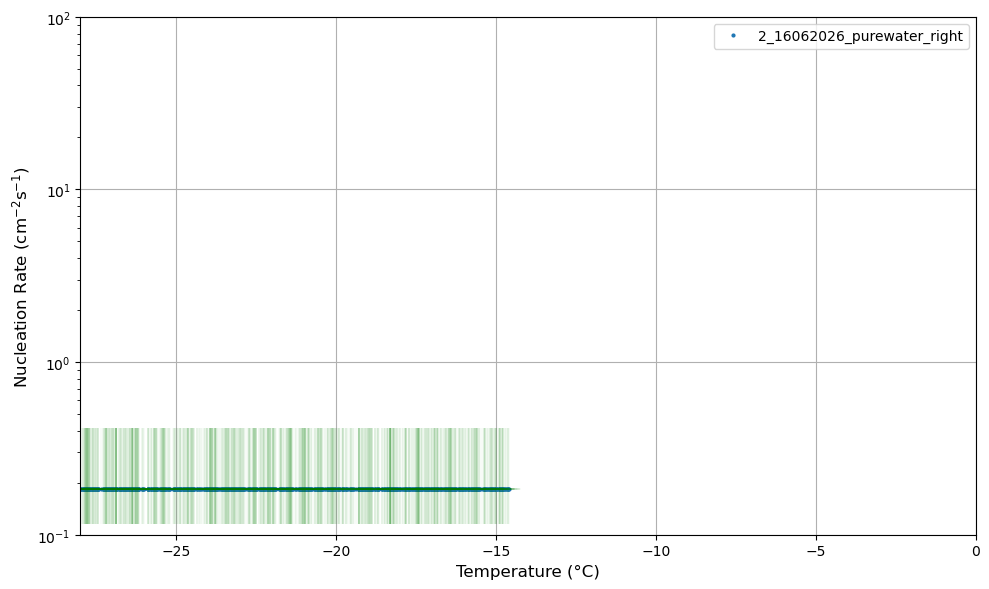

In [20]:
nucleation_rate(
    times_dict={tag: experiment_data[tag]["times"] for tag in labels},  
    temp_dict={tag: experiment_data[tag]["temps"] for tag in labels},  
    num_droplets=96,  
    time_step=1,  
    V_dict={tag: experiment_data[tag]["volume"] for tag in labels},  
    labels=labels,  
    xlim=(-28, 0),  
    ylim=(1e-1, 1e2),  
    colors={tag: color_dict[tag] for tag in labels} 
)

# Homogeneous nucleation rate 

In [21]:
# Constants
T0 = 273.15         # Reference temperature in Kelvin (0°C)
lf = 3.3355 * 10**5    # Latent heat of fusion in J/kg
k = 1.3806 * 10**-23  # Boltzmann constant in J/K
K = float(10**47)   # Prefactor in 1/cm^3s
g_para = 2.591893*10**-20  # From Ickes paper method 
a1 = 0.9167
a2 = -1.75*10**-4
a3 = -5*10**-7
M = 18.015         # Molar mass of water g/mol
N = 6.02214 * 10**23  # Avogadro's number 
rv = 461.5         # Specific gas constant for water vapor
arrayt = np.arange(240,275)  # Temperature range in Kelvin

# Compute supercooling temperature
Tc = arrayt - T0

# Specific volume of ice (m³)
def Vice(T):
    Tc = T - T0
    return (M / ((a1 + a2 * Tc + a3 * Tc**2) * N)) * 10**-6

# Supersaturation ratio
def si(T):
    return lf / (rv * T0) * (T0 / T - 1)

# Surface tension (J/m²), from fitted data
sigma = (29.1 * 10**-3 + 0.1240907 * 10**-3 * Tc)

# Gibbs Free Energy Barrier calculation (J)
def G_barrier(T):
    return (16 * np.pi / 3) * (Vice(T)**2 * (sigma**3)) / ((k * T * si(T))**2)

# Theoretical nucleation rate
# def ln_J(T):
#     G_barrier_T = G_barrier(T)
#     return 10**((np.log(K) - G_barrier_T / (k * T) - g_para / (k * T)) / np.log(10))
def J_theoretical(T):
    G_barrier_T = G_barrier(T)  # Compute Gibbs free energy barrier
    return K * np.exp(-G_barrier_T / (k * T) - g_para / (k * T))


# # Logarithm of theoretical nucleation rate
# def J_theoretical(T):
#     G_barrier_T = G_barrier(T)  # Compute Gibbs free energy barrier
#     J_values = K * np.exp(-G_barrier_T / (k * T) - g_para / (k * T))
#     return J_values

# Function for experimental nucleation rate calculation
def J(frozen_fractions, V, time_step):
    j = []  
    threshold = 0.01  # Define the threshold
    
    for i in range(len(frozen_fractions)):
        if np.isclose(frozen_fractions[i], 1, atol=threshold) or np.isclose(frozen_fractions[i], 0, atol=threshold):
            j.append(np.nan)
        else:
            j_value = -np.log(1 - frozen_fractions[i]) / (V * time_step)
            j.append(j_value)
    
    return np.array(j)

# Error calculation for experimental nucleation rate
def error_J(errors, V, frozen_fractions):
    j_error = []  
    threshold = 0.02  

    for i, f in enumerate(frozen_fractions):
        if np.isclose(f, 1, atol=threshold) or np.isclose(f, 0, atol=threshold):
            j_error.append(np.nan)
        else:
            j_error_value = errors[i] / (2 * V * (1 - f) * np.log(10))
            j_error.append(j_error_value)
    
    return np.array(j_error)

def homogeneous_nucleation_rate(times_dict, temp_dict, num_droplets, V_dict, time_step, labels, colors, names, xlim=None, ylim=None, filename=None):
    """
    Plots experimental nucleation rates and overlays the theoretical values.
    """
    plt.figure(figsize=(10, 6))

    # Plot experimental data
    for idx, label in enumerate(labels):
        times = times_dict[label]
        temp = temp_dict[label]  # Assuming this is in Celsius
        V = V_dict[label]
        color = colors.get(label)
        name = names.get(label)

        # Compute frozen fraction
        frozen_fractions = np.zeros(len(temp))
        for i in range(len(times)):
            frozen_fractions[int(times[i]):] += 1 / num_droplets

        err_temp = 0.3 + 0.005 * np.abs(temp)

        lower_bound, upper_bound = confidence_interval_95(frozen_fractions, num_droplets)
        error_bars_lower = np.abs(frozen_fractions - lower_bound)
        error_bars_upper = np.abs(upper_bound - frozen_fractions)

        y_error_up = error_J(error_bars_upper, V, frozen_fractions)
        y_error_down = error_J(error_bars_lower, V, frozen_fractions)

        plt.plot(temp, J(frozen_fractions, V, time_step), 'o', color=color, label=name, markersize=2)
        plt.errorbar(temp, J(frozen_fractions, V, time_step),
                     yerr=[y_error_down, y_error_up],
                     xerr=[err_temp], 
                     fmt='none', color=color, alpha=0.03)

    # Overlay theoretical nucleation rate (now correctly in log10 scale)
    plt.plot(arrayt - T0, J_theoretical(arrayt), label="Theoretical Nucleation Rate", linestyle="--", color="black")

    # Plot customization
    plt.xlabel('Temperature (°C)', fontsize=12)
    plt.ylabel('Nucleation Rate (1/(s·cm³))', fontsize=12)  # Fixed label
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.yscale('log')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # Save or show the plot
    if filename:
        plt.savefig(filename)
    plt.show()


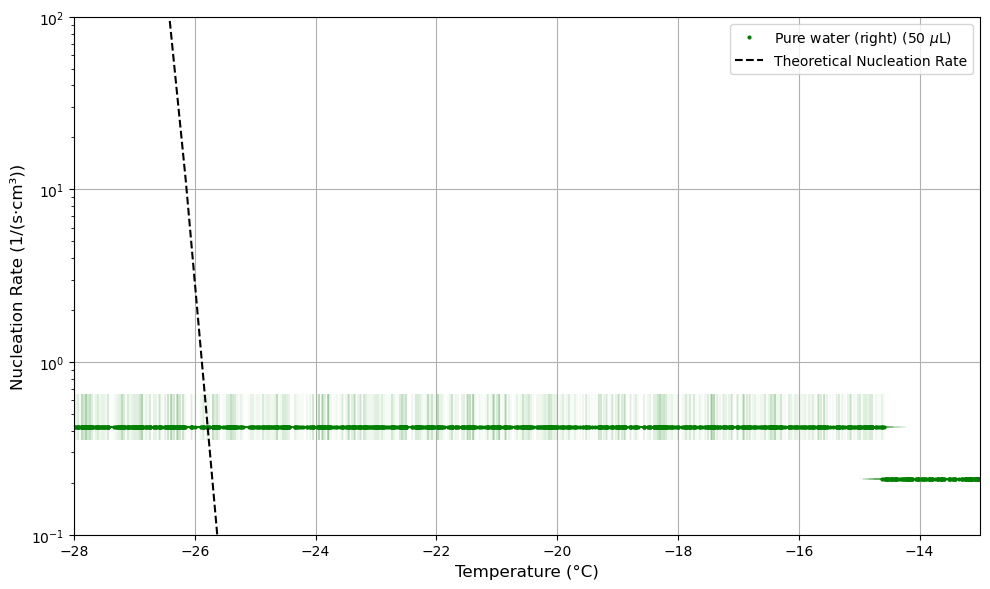

In [22]:
# labels = ["20250130_purewater_50microL",
#         "20250130_purewater_100microL",
#         "20250212_purewater_1", 
#         "20250212_purewater_2", 
#         "14okt_purewater_50microL",
#         "14okt_purewater_100microL",
#         "15okt_Thermmass"
# ]

homogeneous_nucleation_rate(
    times_dict={tag: experiment_data[tag]["times"] for tag in labels},  
    temp_dict={tag: experiment_data[tag]["temps"] for tag in labels},  
    num_droplets=96,  
    time_step=1,  
    V_dict={tag: experiment_data[tag]["volume"] for tag in labels},  
    labels=labels,  
    xlim=(-28,-13),  
    ylim=(1e-1, 1e2),  
    colors={tag: color_dict[tag] for tag in labels}, 
    names={tag: name_dict[tag] for tag in labels}, 
    filename = "homogeneous_nucleation_rate"
)